<div align="center">

# 🌳 Customer Segmentation Using Decision Tree Classification

### Online Retail Dataset

*Implementing the ID3 algorithm to analyze customer purchasing behavior and identify the factors that influence customer segments*

</div>

---

## 📚 1. Import Required Libraries

*Importing the libraries required for data preprocessing, model development, evaluation, and decision tree visualization.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 📂 2. Load the Online Retail Dataset

*Loading the Online Retail dataset and examining its initial records and structural information.*

In [3]:
df = pd.read_excel("Online Retail.xlsx")
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

## 🧹 3. Handle Missing Customer Information

*Removing transactions with missing CustomerID values to ensure reliable customer-level analysis.*

In [5]:
df = df.dropna(subset=["CustomerID"])

## 🚫 4. Remove Cancelled Transactions

*Removing cancelled invoices identified by invoice numbers beginning with "C" to focus the analysis on completed purchases.*

In [6]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

## 🧹 5. Filter Invalid Transactions

*Removing transactions with non-positive quantities or unit prices to ensure that only valid purchase records are used for analysis.*

In [7]:
df = df[df["Quantity"]>0]
df = df[df["UnitPrice"]>0]

## 💰 6. Calculate Total Transaction Amount

*Calculating the total amount spent for each transaction using quantity and unit price.*

In [8]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

## 🔎 7. Verify the Preprocessed Dataset

*Checking the dataset dimensions and previewing the processed records after completing the initial preprocessing steps.*

In [9]:
print(df.shape)
print(df.head())

(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


## 👥 8. Create Customer-Level Features

*Aggregating transaction-level data by CustomerID to create meaningful features that represent individual customer purchasing behavior.*

In [13]:
customer_data = df.groupby("CustomerID").agg(
    TotalSpend=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    NumberOfProducts=("StockCode", "nunique"),
    AverageOrderValue=("TotalAmount", "mean"),
    Country=("Country", "first")
).reset_index()
print(customer_data.head())

   CustomerID  TotalSpend  TotalQuantity  NumberOfTransactions  \
0     12346.0    77183.60          74215                     1   
1     12347.0     4310.00           2458                     7   
2     12348.0     1797.24           2341                     4   
3     12349.0     1757.55            631                     1   
4     12350.0      334.40            197                     1   

   NumberOfProducts  AverageOrderValue         Country  
0                 1       77183.600000  United Kingdom  
1               103          23.681319         Iceland  
2                22          57.975484         Finland  
3                73          24.076027           Italy  
4                17          19.670588          Norway  


## 🎯 9. Create Customer Segments

*Dividing customers into Low Value, Medium Value, and High Value segments based on their total spending using quantile-based segmentation.*

In [14]:
customer_data["Segment"] = pd.qcut(
    customer_data["TotalSpend"],
    q=3,
    labels=["Low Value", "Medium value", "High Value"]
)
print(customer_data["Segment"].value_counts())

Segment
Low Value       1446
Medium value    1446
High Value      1446
Name: count, dtype: int64


## 🎯 10. Define Features and Target Variable

*Selecting customer purchasing behavior features as inputs and using the customer segment as the target variable for classification.*

In [15]:
features = [
    "TotalQuantity",
    "NumberOfTransactions",
    "NumberOfProducts",
    "AverageOrderValue"
]
X = customer_data[features]
y = customer_data["Segment"]

## ✂️ 11. Split the Dataset into Training and Testing Sets

*Splitting the customer data into training and testing sets while preserving the proportion of each customer segment.*

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 🌳 12. Implement the ID3 Decision Tree Classifier

*Training a Decision Tree classifier using entropy-based splitting, which follows the ID3 approach, to classify customers into purchasing behavior segments.*

In [18]:
id3_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=4
)
id3_model.fit(X_train, y_train)
y_pred = id3_model.predict(X_test)
print("Predictions:")
print(y_pred[:20])

Predictions:
['Low Value' 'Low Value' 'Low Value' 'Low Value' 'Medium value'
 'Low Value' 'Low Value' 'High Value' 'Low Value' 'Medium value'
 'Low Value' 'Medium value' 'High Value' 'High Value' 'High Value'
 'High Value' 'Low Value' 'Low Value' 'High Value' 'Low Value']


## 📊 13. Evaluate the ID3 Model

*Evaluating the decision tree using accuracy, precision, recall, and F1-score to measure its classification performance across customer segments.*

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8467741935483871

Classification Report:
              precision    recall  f1-score   support

  High Value       0.93      0.87      0.90       289
   Low Value       0.87      0.85      0.86       289
Medium value       0.75      0.82      0.78       290

    accuracy                           0.85       868
   macro avg       0.85      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868



## 🔢 14. Generate the Confusion Matrix

*Visualizing the classification results to examine how accurately the ID3 decision tree distinguishes between the different customer segments.*

In [20]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[251   2  36]
 [  0 247  42]
 [ 19  34 237]]


## 🌳 15. Visualize the ID3 Decision Tree

*Visualizing the learned decision tree to understand how customer purchasing features are used to classify customers into different segments.*

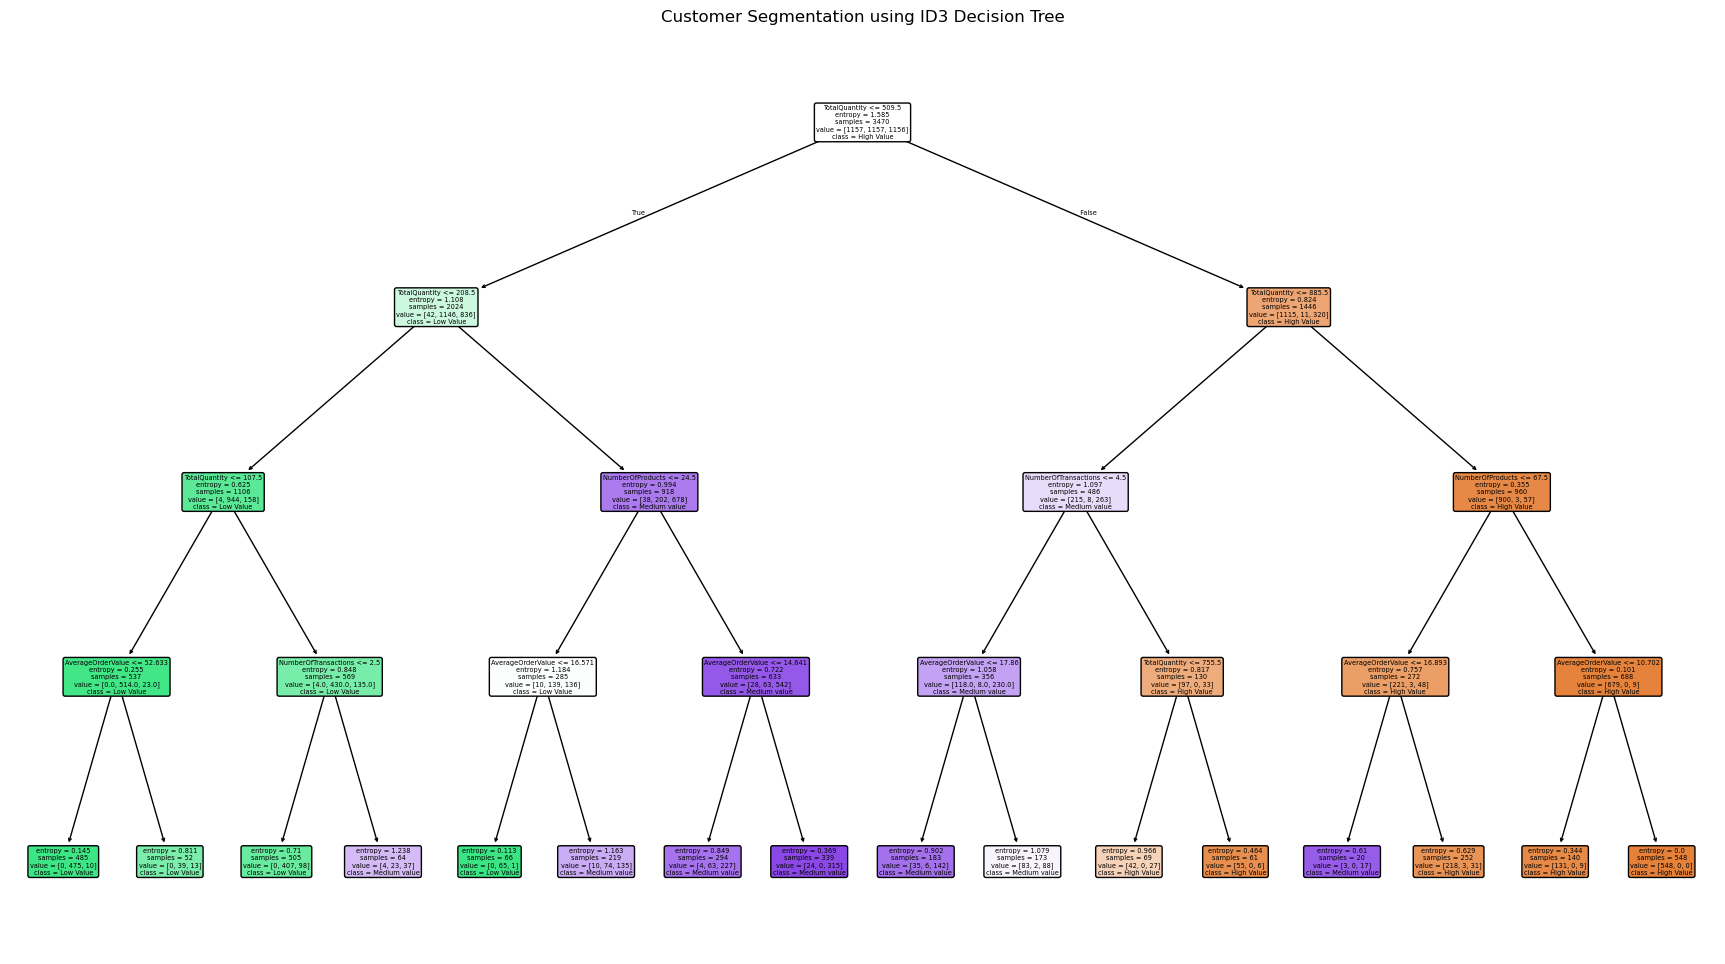

In [24]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": id3_model.feature_importances_
})
importance_sorted = importance.sort_values(
    "Importance",
    ascending=True
)
plt.figure(figsize=(22, 12))
plot_tree(
    id3_model,
    feature_names=features,
    class_names=id3_model.classes_,
    filled=True,
    rounded=True,
    proportion=False
)
plt.title("Customer Segmentation using ID3 Decision Tree")
plt.show()

## ⭐ 16. Analyze Feature Importance

*Measuring the relative importance of each customer behavior feature to understand which purchasing characteristics contribute most to customer segmentation.*

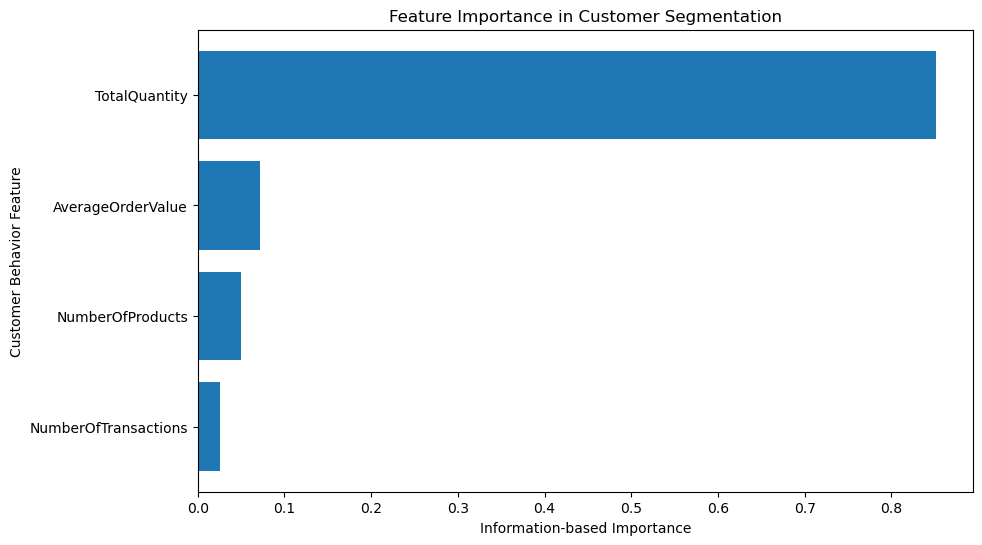

In [26]:
plt.figure(figsize=(10,6))
plt.barh(
    importance_sorted["Feature"],
    importance_sorted["Importance"]
)
plt.xlabel("Information-based Importance")
plt.ylabel("Customer Behavior Feature")
plt.title("Feature Importance in Customer Segmentation")
plt.show()